Какую бизнес-задачу мы решаем?

Мы будем решать задачу **прогнозирования конверсии в покупку (Purchase Conversion Prediction)**.

Математически: задачу **бинарной классификации**

Алгоритмы: **Random Forest**, **CatBoost**

- **Контекст:** Пользователи заходят на сайт, добавляют товары в корзину, смотрят отзывы, кликают по баннерам. Часть из них покупает (класс 1), но большинство уходит без покупки (класс 0).
- **Бизнес-проблема:** Тратить маркетинговый бюджет на рекламу и скидки для _всех_ пользователей подряд — это огромные убытки.
- **Как наша модель поможет бизнесу:**
    1. **Экономия на скидках:** Если модель видит, что пользователь сомневается (вероятность покупки `0.45`), ему автоматически выскочит поп-ап с промокодом на 5%, чтобы «дожать» до покупки. Если пользователь и так купит (вероятность `0.95`), скидку ему не дадут, сэкономив деньги компании.
    2. **Персонализация рекламы:** Мы не будем спамить пуш-уведомлениями тех, у кого вероятность покупки близка к нулю (класс 0), чтобы они не удалили приложение.


Шаг 1. Создание реалистичного E-commerce датасета (100 000 сессий)Генерируем датасет, где поведение пользователей напрямую (но нелинейно) связано с тем, купят они товар или нет. Также добавляем категориальный признак устройства.


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

np.random.seed(42)
n_samples = 100000

# Генериурем поведенческие признаки
pages_visited = np.random.poisson(lam=4, size=n_samples) + 1
session_duration = pages_visited * np.random.exponential(scale=3, size=n_samples) + np.random.normal(5, 2, n_samples)
basket_additions = np.random.binomial(n=pages_visited, p=0.3)
user_tenure_days = np.random.geometric(p=0.005, size=n_samples)
is_discount_active = np.random.binomial(n=1, p=0.4, size=n_samples)
device_type = np.random.choice(['Mobile', 'Desktop', 'Tablet'], size=n_samples, p=[0.6, 0.3, 0.1])

# Формируем скрытую лоигку для совершения покупки (Target)
# Логика: много добавлений в корзину + скидка + долгое время на сайте = высокая вероятность покупки
score = (basket_additions * 2.0) + (session_duration * 0.05) + (is_discount_active * 0.7) - 3.5
proba = 1 / (1 + np.exp(-score)) # Сигмоида для перевода в вероятность
is_purchased = np.random.binomial(n=1, p=proba)

df = pd.DataFrame({
    'pages_visited': pages_visited,
    'session_duration': np.clip(session_duration, 0, None), # убираем отрицательное время
    'basket_additions': basket_additions,
    'user_tenure_days': user_tenure_days,
    'is_discount_active': is_discount_active,
    'device_type': device_type,
    'is_purchased': is_purchased
})

print(f"Датасет успешно создан! Размер: {df.shape}")
print(f"Баланс классов (покупки): \n{df['is_purchased'].value_counts(normalize=True)}")


Шаг 2. Предобработка данных (One-Hot Encoding) и деление на выборкиПоскольку RandomForest не умеет работать со строками, мы превратим признак device_type в три числовые колонки с помощью One-Hot Encoding.

In [ ]:
# 1. Сначала кодируем device_type из исходного df (который мы создали на Шаге 1)
df_encoded = pd.get_dummies(df, columns=['device_type'], drop_first=True, dtype=int)

# 2. Теперь разделяем на признаки и целевую переменную
X = df_encoded.drop(columns=['is_purchased'])
y = df_encoded['is_purchased']

# 3. Первый сплит: выделяем Train (60%) и временный остаток Temp (40%)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42, stratify=y)

# 4. Второй сплит: делим Temp ровно пополам на Val (20%) и Test (20%)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"Обучение: {X_train.shape} строк | Валидация: {X_val.shape} строк | Тест: {X_test.shape} строк")


Шаг 3. Поиск лучших параметров Random Forest через Optuna

In [ ]:
import optuna
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

# Отключаем лишний спам в логах, смотрим только на финал
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective_rf(trial):
    # Описываем сетку параметров, которую Optuna будет исследовать
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 200, step=50),
        'max_depth': trial.suggest_int('max_depth', 6, 16),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 4),
        'random_state': 42,
        'n_jobs': -1
    }
    
    # Инициализируем и обучаем модель на тренировочном сете (60k строк)
    model = RandomForestClassifier(**params)
    model.fit(X_train, y_train)
    
    # Считаем предсказания на валидационном сете (20k строк)
    preds = model.predict_proba(X_val)[:, 1]
    return roc_auc_score(y_val, preds)

# Запуск исследования
study_rf = optuna.create_study(direction='maximize')
print("Optuna подбирает параметры для Random Forest...")
study_rf.optimize(objective_rf, n_trials=10) # 10 итераций для баланса скорости и качества

print("\n--- Результаты Random Forest ---")
print(f"Лучшие параметры: {study_rf.best_params}")
print(f"Лучший ROC-AUC на валидации: {study_rf.best_value:.4f}")


Шаг 4. Подбор параметров через Optuna для CatBoost

In [ ]:
from catboost import CatBoostClassifier

def objective_cb(trial):
    # Задаем параметры для бустинга
    params = {
        'iterations': trial.suggest_int('iterations', 100, 400, step=50),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'depth': trial.suggest_int('depth', 4, 8),
        'random_state': 42,
        'verbose': 0 # Чтобы логи CatBoost не забивали экран
    }
    
    # Обучаем на тренировочных данных
    model = CatBoostClassifier(**params)
    model.fit(X_train, y_train)
    
    # Оцениваем качество на валидационном сете
    preds = model.predict_proba(X_val)[:, 1]
    return roc_auc_score(y_val, preds)

# Запускаем исследование Optuna для CatBoost
study_cb = optuna.create_study(direction='maximize')
print("Optuna подбирает параметры для CatBoost...")
study_cb.optimize(objective_cb, n_trials=10)

print("\n--- Результаты CatBoost ---")
print(f"Лучшие параметры: {study_cb.best_params}")
print(f"Лучший ROC-AUC на валидации: {study_cb.best_value:.4f}")


Шаг 5. Объединение в Стекинг и Финальный Баттл

In [ ]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

# 1. Объединяем тренировочный и валидационный сеты для финального обучения
# Это даст моделям больше данных перед выходом на тест
X_full_train = pd.concat([X_train, X_val])
y_full_train = pd.concat([y_train, y_val])

# 2. Инициализируем базовые модели с лучшими параметрами от Optuna
best_rf = RandomForestClassifier(**study_rf.best_params, random_state=42, n_jobs=-1)
best_cb = CatBoostClassifier(**study_cb.best_params, random_state=42, verbose=0)

# 3. Собираем ансамбль. Мета-модель — логистическая регрессия
estimators = [('rf', best_rf), ('cb', best_cb)]
stacking_model = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(),
    cv=3, # Кросс-валидация для предотвращения утечки данных при обучении мета-модели
    n_jobs=-1
)

# 4. Обучаем одиночные модели и Стекинг на полных данных
print("Обучаем финальные модели на объединенных данных...")
best_rf.fit(X_full_train, y_full_train)
best_cb.fit(X_full_train, y_full_train)
stacking_model.fit(X_full_train, y_full_train)

# 5. Считаем финальный ЧЕСТНЫЙ ROC-AUC на отложенном тест-сете X_test
rf_auc = roc_auc_score(y_test, best_rf.predict_proba(X_test)[:, 1])
cb_auc = roc_auc_score(y_test, best_cb.predict_proba(X_test)[:, 1])
stack_auc = roc_auc_score(y_test, stacking_model.predict_proba(X_test)[:, 1])

print("\n" + "="*40)
print("  ФИНАЛЬНЫЙ БАТТЛ НА ДАННЫХ E-COMMERCE  ")
print("="*40)
print(f"Оптимизированный Random Forest: {rf_auc:.5f}")
print(f"Оптимизированный CatBoost:     {cb_auc:.5f}")
print(f"Финальный Стекинг (Ансамбль):  {stack_auc:.5f}")
print("="*40)


Feature Importance (важность признаков)

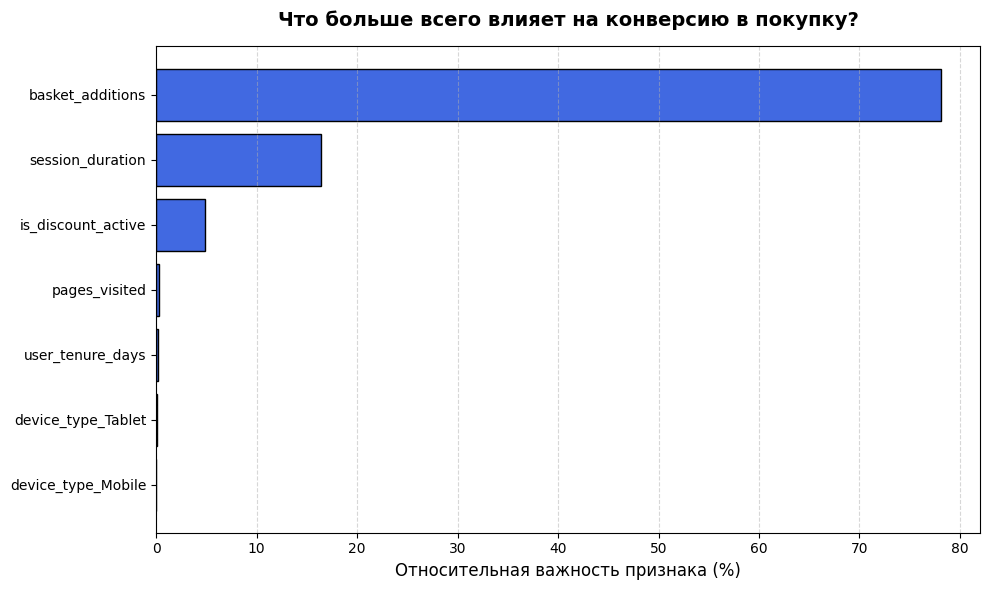

In [6]:
import matplotlib.pyplot as plt
import pandas as pd

# Получаем важность признаков из обученного CatBoost
feature_importances = best_cb.get_feature_importance()
feature_names = X_full_train.columns

# Создаем DataFrame для удобной сортировки
importance_df = pd.DataFrame({
    'Признак': feature_names,
    'Важность': feature_importances
}).sort_values(by='Важность', ascending=True)

# Строим красивый горизонтальный график
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Признак'], importance_df['Важность'], color='royalblue', edgecolor='black')

plt.title('Что больше всего влияет на конверсию в покупку?', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Относительная важность признака (%)', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


Шаг 6. Поиск оптимального порога прибыли

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Получаем предсказанные CatBoost вероятности для тест-сета
# (используем модель best_cb, которую обучили ранее)
test_probs = best_cb.predict_proba(X_test)[:, 1]
y_true = y_test.values

# 2. Массив возможных порогов
thresholds = np.linspace(0.01, 0.99, 100)
total_profits = []

# 3. Симулируем прибыль для каждого порога
for t in thresholds:
    # Если вероятность выше порога — скидку НЕ даем (ждем покупку за полную стоимость)
    # Если ниже порога — ДАЕМ скидку (активируем удержание)
    give_discount = test_probs < t
    
    profit = 0
    for i in range(len(y_true)):
        real_action = y_true[i] # 1 - купил, 0 - ушел
        
        if not give_discount[i]: # Скидку не дали
            if real_action == 1:
                profit += 1000  # Купил сам
            else:
                profit += 0     # Ушел без скидки
        else: # Дали скидку
            # 30% шанс, что сомневающийся (или уходящий) клиент купит со скидкой
            if np.random.rand() < 0.3 or real_action == 1: 
                profit += 800   # Купил со скидкой
            else:
                profit += 0     # Все равно ушел
                
    total_profits.append(profit)

# 4. Находим точку максимума
best_index = np.argmax(total_profits)
best_threshold = thresholds[best_index]
max_profit = total_profits[best_index]

# Прибыль при стандартном подходе (без всяких моделей, даем скидку всем подряд)
baseline_profit = sum([800 if y == 1 else 0 for y in y_true]) # грубый подсчет

print(f"Математически оптимальный порог: {best_threshold:.2f}")
print(f"Максимальная прибыль с модели: {max_profit:,.0f} руб.")


Математически оптимальный порог: 0.61
Максимальная прибыль с модели: 12,668,400 руб.


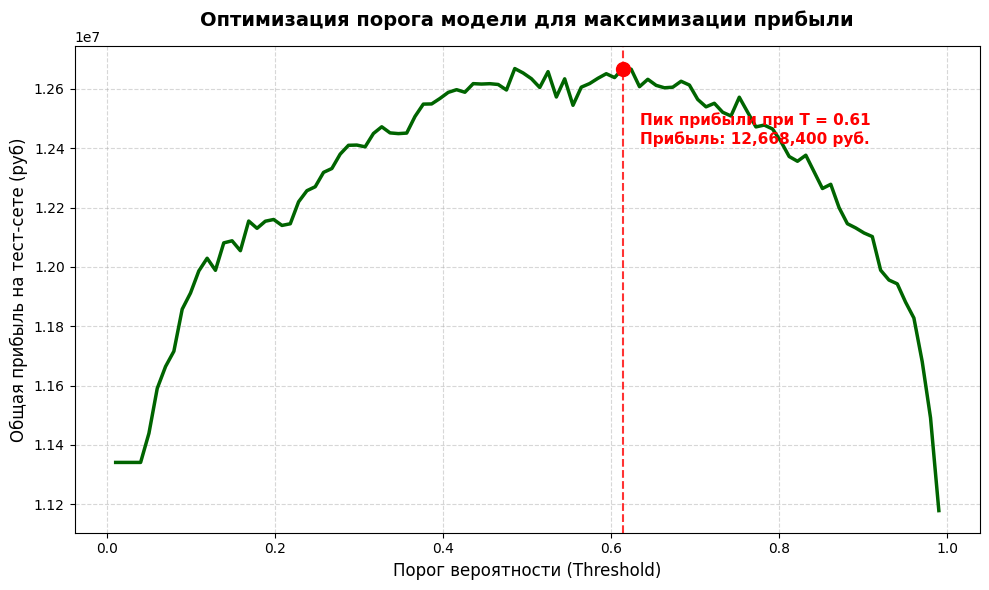

In [8]:
plt.figure(figsize=(10, 6))
plt.plot(thresholds, total_profits, color='darkgreen', linewidth=2.5, label='Прибыль компании')

# Выделяем оптимальную точку
plt.axvline(best_threshold, color='red', linestyle='--', alpha=0.8)
plt.scatter(best_threshold, max_profit, color='red', s=100, zorder=5)

plt.title('Оптимизация порога модели для максимизации прибыли', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Порог вероятности (Threshold)', fontsize=12)
plt.ylabel('Общая прибыль на тест-сете (руб)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

# Добавляем текстовую аннотацию на график
plt.text(best_threshold + 0.02, max_profit * 0.98, 
         f'Пик прибыли при T = {best_threshold:.2f}\nПрибыль: {max_profit:,.0f} руб.', 
         fontsize=11, color='red', fontweight='bold')

plt.tight_layout()
plt.show()
